In [2]:
# Libraries for data processing and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc
)

In [3]:
# Loaded the dataset
DATA_PATH = "olist_orders_dataset.csv"
orders = pd.read_csv(DATA_PATH)
print("Rows raw:", len(orders))

# Filtered only delivered orders for target creation
orders = orders[orders["order_status"] == "delivered"].copy()
print("Rows delivered:", len(orders))

# Selected key delivery-related date columns
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

# Converted date columns to datetime format
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

# Sanity check: delivery should not occur before purchase
invalid = (
    orders["order_delivered_customer_date"] <
    orders["order_purchase_timestamp"]
).sum()

print("Invalid rows (delivery before purchase):", invalid)

# Removed inconsistent records where delivery occurred before purchase
orders = orders[
    orders["order_delivered_customer_date"] >=
    orders["order_purchase_timestamp"]
].copy()

# Dropped rows with missing key delivery dates
orders = orders.dropna(subset=date_cols).copy()
print("Rows after dropping missing key dates:", len(orders))

Rows raw: 99441
Rows delivered: 96478
Invalid rows (delivery before purchase): 0
Rows after dropping missing key dates: 96470


In [4]:
# Target variable creation
orders["late_delivery"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
).astype(int)

# Removed rows with missing target values
orders = orders.dropna(subset=["late_delivery"]).copy()

# Checked class distribution (normalized)
orders["late_delivery"].value_counts(normalize=True)

late_delivery
0    0.918876
1    0.081124
Name: proportion, dtype: float64

In [5]:
# Created summary statistics for the cleaned dataset

summary_rows = [
    ("Final cleaned dataset", len(orders)),
    ("Late delivery rate (%)", round(orders["late_delivery"].mean() * 100, 2)),
]

# Converted summary statistics into a table
table1 = pd.DataFrame(summary_rows, columns=["Description", "Value"])

# Displayed the dataset summary
table1

,Description,Value
0,Final cleaned dataset,96470.00
1,Late delivery rate (%),8.11


In [6]:
# Feature creation for analysis and modelling

# Created promised delivery duration (purchase to estimated delivery)
orders["promised_days"] = (
    orders["order_estimated_delivery_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# Created actual delivery duration (used for analysis only)
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

# Extracted purchase-time features
orders["purchase_hour"] = orders["order_purchase_timestamp"].dt.hour
orders["purchase_dayofweek"] = orders["order_purchase_timestamp"].dt.dayofweek
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month

In [7]:
# Checked remaining missing values after cleaning
orders.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
late_delivery                     0
promised_days                     0
delivery_time_days                0
purchase_hour                     0
purchase_dayofweek                0
purchase_month                    0
dtype: int64

In [8]:
# Verified target variable construction
orders[[
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "late_delivery"
]].head()

,order_delivered_customer_date,order_estimated_delivery_date,late_delivery
0,2017-10-10 21:25:13,2017-10-18,0
1,2018-08-07 15:27:45,2018-08-13,0
2,2018-08-17 18:06:29,2018-09-04,0
3,2017-12-02 00:28:42,2017-12-15,0
4,2018-02-16 18:17:02,2018-02-26,0


In [9]:
# Checked class distribution and late delivery rate
vc = orders["late_delivery"].value_counts()
print(vc)

print("\nLate rate (%):", (vc[1] / vc.sum()) * 100)

late_delivery
0    88644
1     7826
Name: count, dtype: int64

Late rate (%): 8.112366538820359


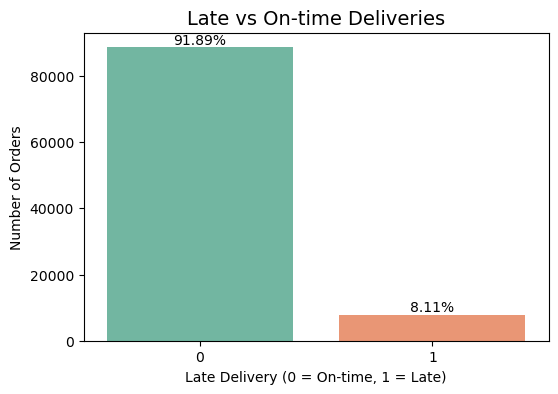

In [10]:
# Plotted class distribution to check late vs on-time imbalance
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="late_delivery",
    data=orders,
    hue="late_delivery",
    palette="Set2",
    legend=False
)

# Added percentage labels on bars
total = len(orders)
for p in ax.patches:
    percentage = f"{(p.get_height() / total) * 100:.2f}%"
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha="center", va="bottom")

plt.title("Late vs On-time Deliveries", fontsize=14)
plt.xlabel("Late Delivery (0 = On-time, 1 = Late)")
plt.ylabel("Number of Orders")

plt.show()

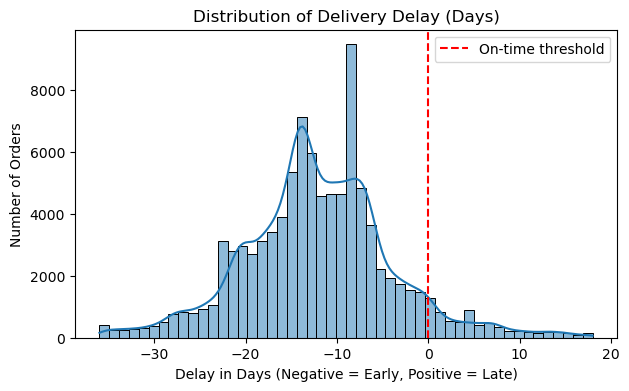

Mean delay: -11.88
Median delay: -12.0


In [11]:
# Calculated delivery delay in days (EDA only)
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_estimated_delivery_date"]
).dt.days

plt.figure(figsize=(7,4))

# Removed missing delay values
delay = orders["delivery_delay_days"].dropna()

# Removed extreme values (1% tails) for clearer distribution
lower = delay.quantile(0.01)
upper = delay.quantile(0.99)
delay_clean = delay[(delay >= lower) & (delay <= upper)]

# Plotted delay distribution
sns.histplot(delay_clean, bins=50, kde=True)

# Marked zero as on-time threshold
plt.axvline(0, color="red", linestyle="--", label="On-time threshold")

plt.title("Distribution of Delivery Delay (Days)")
plt.xlabel("Delay in Days (Negative = Early, Positive = Late)")
plt.ylabel("Number of Orders")
plt.legend()

plt.show()

# Calculated mean and median delay
print("Mean delay:", round(delay.mean(), 2))
print("Median delay:", round(delay.median(), 2))

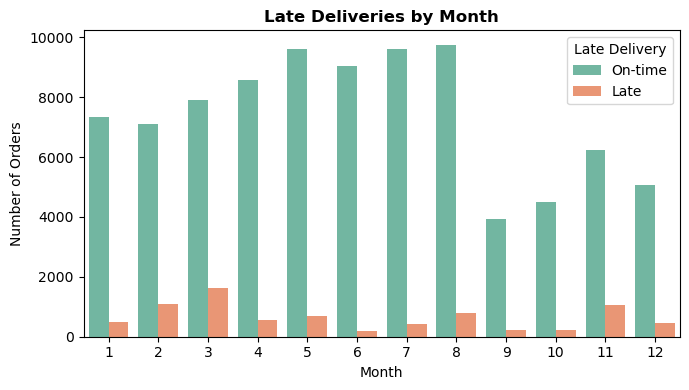

In [12]:
plt.figure(figsize=(7,4))

# Plotted number of orders by month (split by late vs on-time)
sns.countplot(x="purchase_month", hue="late_delivery", data=orders, palette="Set2")

plt.title("Late Deliveries by Month", weight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.legend(title="Late Delivery", labels=["On-time", "Late"])

plt.tight_layout()
plt.show()

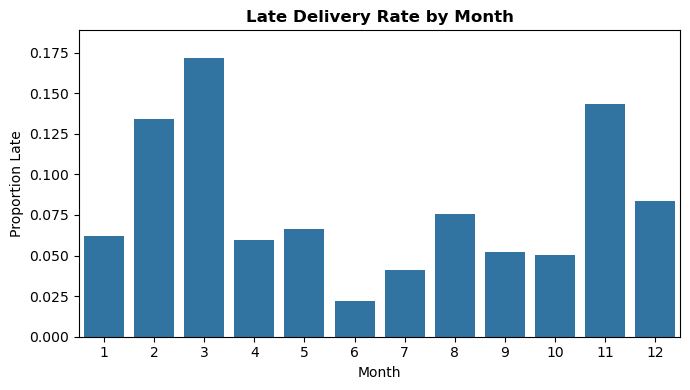

In [13]:
# Calculated late delivery rate by month
late_by_month = (
    orders.groupby("purchase_month")["late_delivery"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))

# Plotted monthly late delivery proportion
sns.barplot(data=late_by_month, x="purchase_month", y="late_delivery")

plt.title("Late Delivery Rate by Month", weight="bold")
plt.xlabel("Month")
plt.ylabel("Proportion Late")

# Adjusted y-axis slightly above max value for clarity
plt.ylim(0, late_by_month["late_delivery"].max() * 1.1)

plt.tight_layout()
plt.show()

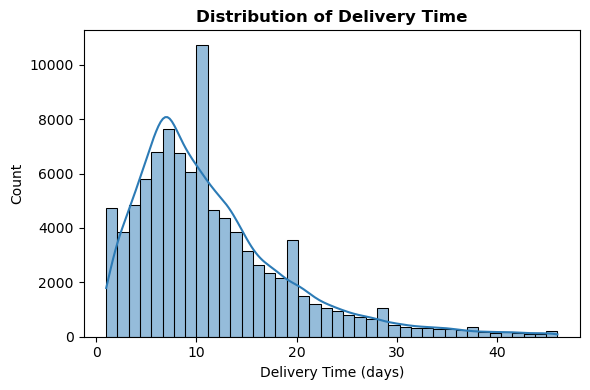

Mean delivery time (days): 12.09
Median delivery time (days): 10.0


In [14]:
# Distribution of actual delivery time (removed extreme 1% tails)

plt.figure(figsize=(6,4))

# Took delivery time in days
delivery = orders["delivery_time_days"].dropna()

# Removed extreme values (below 1% and above 99%) to avoid distortion
lower = delivery.quantile(0.01)
upper = delivery.quantile(0.99)
delivery_clean = delivery[(delivery >= lower) & (delivery <= upper)]

# Plotted the distribution
sns.histplot(delivery_clean, bins=40, kde=True, color="#2C7BB6")

plt.title("Distribution of Delivery Time", weight="bold")
plt.xlabel("Delivery Time (days)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Calculated mean and median to summarise delivery performance
print("Mean delivery time (days):", round(delivery.mean(), 2))
print("Median delivery time (days):", round(delivery.median(), 2))

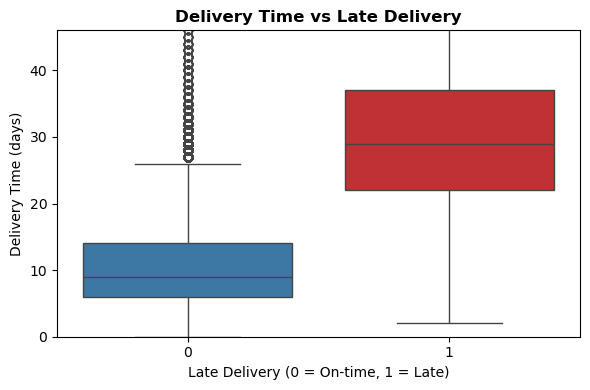

In [15]:
# Compared delivery time between on-time and late orders
plt.figure(figsize=(6,4))

sns.boxplot(
    x="late_delivery",
    y="delivery_time_days",
    hue="late_delivery",
    data=orders,
    palette=["#2C7BB6", "#D7191C"],
    legend=False
)

# Limited y-axis to 99th percentile to reduce effect of extreme outliers
plt.ylim(0, orders["delivery_time_days"].quantile(0.99))

plt.title("Delivery Time vs Late Delivery", weight="bold")
plt.xlabel("Late Delivery (0 = On-time, 1 = Late)")
plt.ylabel("Delivery Time (days)")

plt.tight_layout()
plt.show()

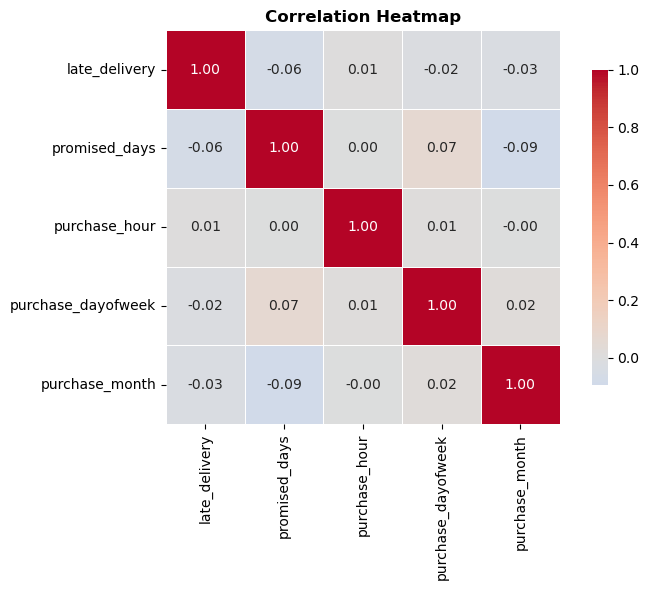

In [16]:
# Selected key numerical features
features_for_corr = [
    "late_delivery",
    "promised_days",
    "purchase_hour",
    "purchase_dayofweek",
    "purchase_month"
]

# Calculated correlation matrix
corr = orders[features_for_corr].corr()

plt.figure(figsize=(8,6))

# Plotted correlation heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap", weight="bold")
plt.tight_layout()
plt.show()

In [17]:
# Checked correlations with late_delivery across all numerical variables
corr = orders.corr(numeric_only=True)
print(corr["late_delivery"].sort_values())

promised_days         -0.059801
purchase_month        -0.025390
purchase_dayofweek    -0.015293
purchase_hour          0.008667
delivery_time_days     0.589953
delivery_delay_days    0.605308
late_delivery          1.000000
Name: late_delivery, dtype: float64


In [18]:
# Removed rows with missing modelling features
orders = orders.dropna(subset=[
    "purchase_hour",
    "purchase_dayofweek",
    "purchase_month",
    "promised_days"
]).copy()

# Checked final dataset size
orders.shape

(96470, 15)

In [19]:
# Examined summary statistics of modelling features
orders[["promised_days", "purchase_hour", "purchase_dayofweek", "purchase_month"]].describe()

,promised_days,purchase_hour,purchase_dayofweek,purchase_month
count,96470.000000,96470.000000,96470.000000,96470.000000
mean,23.372748,14.773028,2.756494,6.031046
std,8.758421,5.328347,1.967041,3.228479
min,2.000000,0.000000,0.000000,1.000000
25%,18.000000,11.000000,1.000000,3.000000
50%,23.000000,15.000000,3.000000,6.000000
75%,28.000000,19.000000,4.000000,8.000000
max,155.000000,23.000000,6.000000,12.000000


In [20]:
# Defined modelling features and target variable
features = [
    "purchase_hour",
    "purchase_dayofweek",
    "purchase_month",
    "promised_days"
]

# Created feature matrix (X) and target variable (y)
X = orders[features]
y = orders["late_delivery"]

# Split data into training and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Checked dataset sizes and class balance
print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train late rate:", round(y_train.mean(), 4))
print("Test late rate:", round(y_test.mean(), 4))

Train size: 77176
Test size: 19294
Train late rate: 0.0811
Test late rate: 0.0811


In [21]:
# Trained Dummy classifier (majority class baseline)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Dummy Late Recall:", recall_score(y_test, y_pred_dummy, pos_label=1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy, zero_division=0))

Dummy Accuracy: 0.9188867005286617
Dummy Late Recall: 0.0

Confusion Matrix:
 [[17729     0]
 [ 1565     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     17729
           1       0.00      0.00      0.00      1565

    accuracy                           0.92     19294
   macro avg       0.46      0.50      0.48     19294
weighted avg       0.84      0.92      0.88     19294



In [22]:
# Summarised Dummy model performance
dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_recall = recall_score(y_test, y_pred_dummy, pos_label=1)

table2 = pd.DataFrame([{
    "Model": "Dummy (most frequent)",
    "Accuracy": round(dummy_accuracy, 3),
    "Recall (Late)": round(dummy_recall, 3),
    "ROC-AUC": 0.500
}])

table2

,Model,Accuracy,Recall (Late),ROC-AUC
0,Dummy (most frequent),0.919,0.0,0.5


In [37]:
# Trained Logistic Regression model (class_weight used for imbalance)
model = LogisticRegression(max_iter=2000, class_weight="balanced")
model.fit(X_train, y_train)

# Predicted test labels and probabilities
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluated model performance
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Stored metrics for model comparison
recall_lr = recall_score(y_test, y_pred, pos_label=1)
roc_lr = roc_auc_score(y_test, y_prob)


Accuracy: 0.5277806571991293

Confusion Matrix:
[[9257 8472]
 [ 639  926]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.52      0.67     17729
           1       0.10      0.59      0.17      1565

    accuracy                           0.53     19294
   macro avg       0.52      0.56      0.42     19294
weighted avg       0.87      0.53      0.63     19294



In [24]:
# Stored Logistic Regression metrics for model comparison
lr_accuracy = accuracy_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred, pos_label=1)
lr_rocauc = roc_auc_score(y_test, y_prob)

table3 = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": round(lr_accuracy, 3),
    "Recall (Late)": round(lr_recall, 3),
    "ROC-AUC": round(lr_rocauc, 3)
}])

table3

,Model,Accuracy,Recall (Late),ROC-AUC
0,Logistic Regression,0.528,0.592,0.576


In [25]:
# Defined Random Forest parameter grid
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

# Performed grid search (optimising recall)
grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Selected best Random Forest model
rf = grid_search.best_estimator_

# Generated predictions
y_pred_rf = rf.predict(X_test)

# Generated predicted probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [26]:
# Stored Random Forest metrics for model comparison
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf, pos_label=1)
rf_rocauc = roc_auc_score(y_test, y_prob_rf)

table4 = pd.DataFrame([{
    "Model": "Random Forest (tuned, thr=0.5)",
    "Accuracy": round(rf_accuracy, 3),
    "Recall (Late)": round(rf_recall, 3),
    "ROC-AUC": round(rf_rocauc, 3),
}])

table4

,Model,Accuracy,Recall (Late),ROC-AUC
0,"Random Forest (tuned, thr=0.5)",0.735,0.557,0.709


In [27]:
# Generated predicted probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Applied default classification threshold
y_pred_rf = (y_prob_rf >= 0.5).astype(int)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Random Forest Late Recall:", recall_score(y_test, y_pred_rf, pos_label=1))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Accuracy: 0.7349953353374106
Random Forest ROC-AUC: 0.7089710600328663
Random Forest Late Recall: 0.5571884984025559

Confusion Matrix:
 [[13309  4420]
 [  693   872]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.75      0.84     17729
           1       0.16      0.56      0.25      1565

    accuracy                           0.73     19294
   macro avg       0.56      0.65      0.55     19294
weighted avg       0.89      0.73      0.79     19294



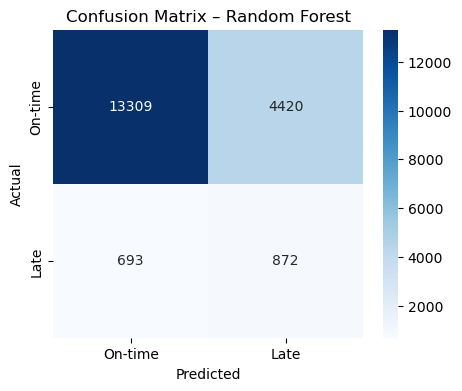

In [28]:
# Computed confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

# Plotted confusion matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["On-time", "Late"],
    yticklabels=["On-time", "Late"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Random Forest")

plt.show()

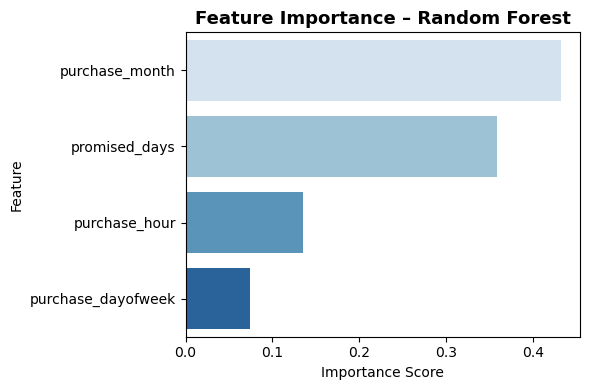

In [29]:
# Extracted Random Forest feature importance
importance = rf.feature_importances_

# Created dataframe with feature importance values
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Plotted feature importance
plt.figure(figsize=(6,4))
sns.barplot(
    x="Importance",
    y="Feature",
    hue="Feature",
    data=feat_imp,
    palette="Blues",
    legend=False,
    order=feat_imp["Feature"]
)

plt.title("Feature Importance – Random Forest", fontsize=13, weight="bold")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [30]:
# Generated predicted probabilities
y_prob = rf.predict_proba(X_test)[:, 1]

# Applied lower classification threshold (0.35)
y_pred_adj = (y_prob >= 0.35).astype(int)

# Evaluated model with adjusted threshold
print(classification_report(y_test, y_pred_adj))
print(confusion_matrix(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       0.96      0.48      0.64     17729
           1       0.12      0.80      0.21      1565

    accuracy                           0.50     19294
   macro avg       0.54      0.64      0.42     19294
weighted avg       0.90      0.50      0.60     19294

[[8472 9257]
 [ 313 1252]]


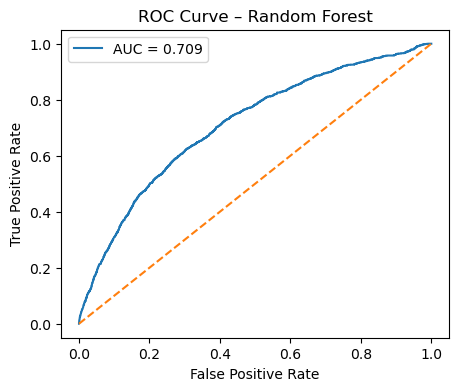

In [31]:
# Computed ROC curve values
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plotted ROC curve
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend()

plt.show()

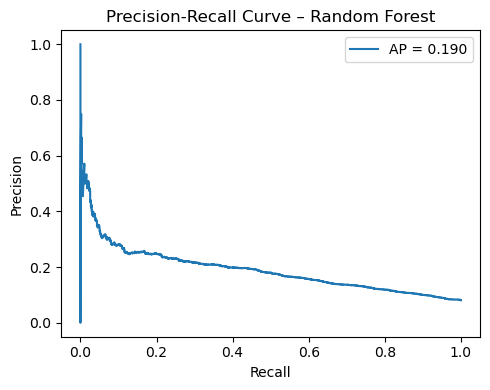

In [32]:
# Computed Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

# Plotted Precision-Recall curve
plt.figure(figsize=(5,4))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – Random Forest")
plt.legend()

plt.tight_layout()
plt.show()

In [33]:
# Final Random Forest metrics 
recall_rf = recall_score(y_test, y_pred_rf, pos_label=1)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Late Recall:", recall_rf)
print("Random Forest ROC-AUC:", roc_rf)

Random Forest Late Recall: 0.5571884984025559
Random Forest ROC-AUC: 0.7089710600328663


In [34]:
# Model comparison summary 

print("Logistic Regression - Late Recall:", recall_lr)
print("Random Forest - Late Recall:", recall_rf)

print("Logistic Regression - ROC AUC:", roc_lr)
print("Random Forest - ROC AUC:", roc_rf)

Logistic Regression - Late Recall: 0.5916932907348242
Random Forest - Late Recall: 0.5571884984025559
Logistic Regression - ROC AUC: 0.575814305436644
Random Forest - ROC AUC: 0.7089710600328663


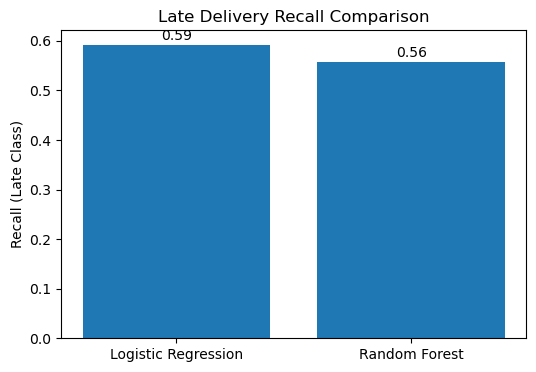

Dummy Late Recall: 0.0
Logistic Regression Late Recall: 0.5916932907348242
Random Forest Late Recall: 0.5571884984025559


In [35]:
# Simple model comparison visualisation

models = ["Logistic Regression", "Random Forest"]
late_recall = [recall_lr, recall_rf]

plt.figure(figsize=(6,4))
plt.bar(models, late_recall)

plt.title("Late Delivery Recall Comparison")
plt.ylabel("Recall (Late Class)")

# Added value labels
for i, v in enumerate(late_recall):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.show()

print("Dummy Late Recall:", dummy_recall)
print("Logistic Regression Late Recall:", recall_lr)
print("Random Forest Late Recall:", recall_rf)

In [36]:
# Created model comparison summary table
comparison_df = pd.DataFrame({
    "Model": ["Dummy", "Logistic Regression", "Random Forest"],
    "Accuracy": [0.919, 0.528, 0.735],
    "Recall (Late)": [0.000, 0.592, 0.557],
    "ROC-AUC": [0.500, 0.576, 0.709]
})

# Displayed model comparison table
comparison_df

,Model,Accuracy,Recall (Late),ROC-AUC
0,Dummy,0.919,0.000,0.500
1,Logistic Regression,0.528,0.592,0.576
2,Random Forest,0.735,0.557,0.709
